In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import warnings
# warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [3]:
print(os.getcwd())

c:\Users\HP\Desktop\Fraud-Detection-System


In [5]:
df=pd.read_csv('dataset/AIML Dataset.csv')

In [6]:
df.shape

(6362620, 11)

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [12]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [19]:
df.shape[0]

6362620

percentage of isFraud 
df['isFraud'].value_counts() gave us the total counts and with [0 ] we selecting the isfraud=1 values  and dividing it by the total number of rows  and multiple by 100 to get the percentage

In [20]:
df['isFraud'].value_counts()[1]/df.shape[0] *100

np.float64(0.12908204481801522)

fraud percentage =0.13

In [21]:
round(df['isFraud'].value_counts()[1]/df.shape[0] *100,2)

np.float64(0.13)

In [22]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [23]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [25]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Cash_out means withdraw (decreases the  balance)

Cash_in  means increasing the balance of the account ( but handled in cash)

DEBIT  is similar to Cash_out but ( money paid from mobile money servise to a BANK account)(the users balance decreaes)

PAYMENT: paying for goods or services to business/merchants ( also decreases the balance of the account/ and increases the balance of the reciever )

TRANSFER : sending money to anotheer user of the service through the mobile money platform


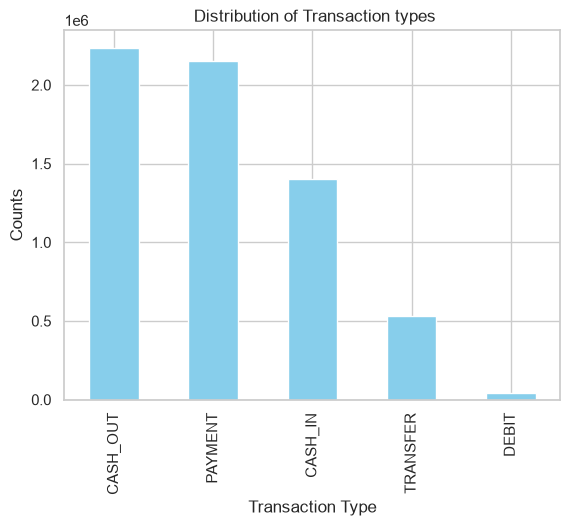

In [26]:
df['type'].value_counts().plot(kind='bar',title=' Distribution of Transaction types',color='skyblue')
plt.xlabel('Transaction Type')
plt.ylabel('Counts')
plt.show()

Most of the transaction type is 
Cash_out < payment < cahs_in < Transfer < Debt

In [29]:
df[['isFraud','type']]

,isFraud,type
0,0,PAYMENT
1,0,PAYMENT
2,1,TRANSFER
3,1,CASH_OUT
4,0,PAYMENT
...,...,...
6362615,1,CASH_OUT
6362616,1,TRANSFER
6362617,1,CASH_OUT
6362618,1,TRANSFER


groupby by type 

and calulating the average of ['isFraud']

which will give us the percentage of fraudulent on the basis of the types

and plot them 

In [34]:
fraud_by_type=df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

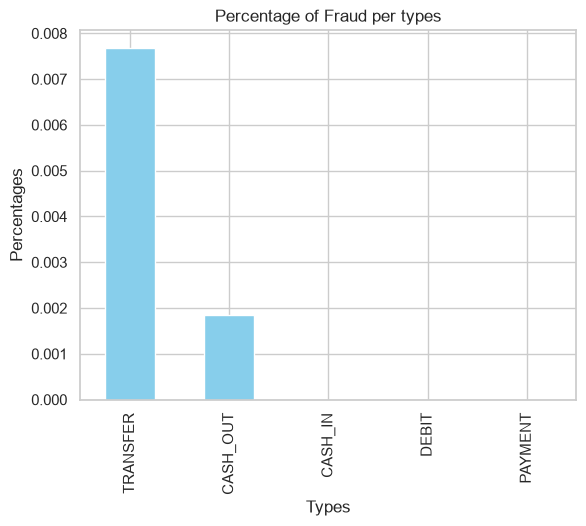

In [35]:
fraud_by_type.plot(kind='bar',title='Percentage of Fraud per types',color='skyblue')
plt.xlabel('Types')
plt.ylabel('Percentages')
plt.show()

Transfer has the Most fraud rate
Second is CahsOut 
others dont have any fraud

In [37]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

# Mean vs MEdian - the skew signal
mean=179,861
median=74,871

mean is 2.4x the median . 

when the mean >> median , it means the small number of very large values(outliers) are dragging the average up(right skew)
median isnt that affected by outliers

# standared deviation > mean ,
 it means the transactions amount are extremely dispered.So the data contains many values that are far from 179,861, especially because of the very large transactions in the upper tail.

How spread out the transaction amounts are around the mean.== Standard Deviation

If transaction amounts were mostly close to 179,861, the standard deviation would be relatively small.


# Quartiles 
where the real mass of data lives
25%: 13,389

50%: 74,871

75%: 208,72

IQR= 20872-13389=195,332
The middle 50% of transaction amounts span 195,332,

Now compare that to the max value which is max: 92,445,516.




df

In a simulated dataset like PaySim, a zero-amount transaction can arise from the simulation's transaction-generation rules

In [38]:
df[df['amount']==0].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736447,212,CASH_OUT,0.0,C1510987794,0.0,0.0,C1696624817,0.00,0.00,1,0
3247298,250,CASH_OUT,0.0,C521393327,0.0,0.0,C480398193,0.00,0.00,1,0
3760289,279,CASH_OUT,0.0,C539112012,0.0,0.0,C1106468520,538547.63,538547.63,1,0
5563714,387,CASH_OUT,0.0,C1294472700,0.0,0.0,C1325541393,7970766.57,7970766.57,1,0
5996408,425,CASH_OUT,0.0,C832555372,0.0,0.0,C1462759334,76759.90,76759.90,1,0


# log1p cause there are 0 transaction rows 

as pbserved there are alot of gaps in the tranactions amount to scale down we use log 
np.log1p(df['amount'])
log

Text(0.5, 0, 'Log(Amount + 1)')

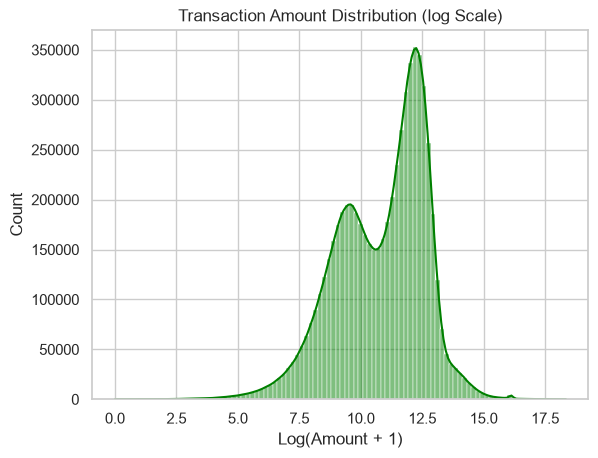

In [39]:
sns.histplot(np.log1p(df['amount']),bins=100,kde=True,color='green')
plt.title('Transaction Amount Distribution (log Scale)')
plt.xlabel('Log(Amount + 1)')

what does the amount vs isFraud relationship look like for smaller transactions only,"

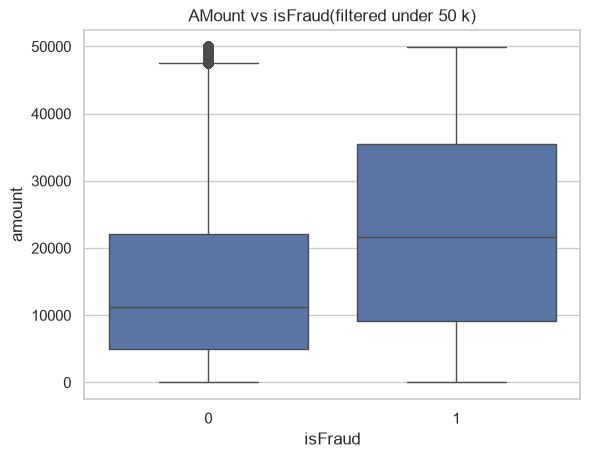

In [41]:
sns.boxplot(data=df[df['amount']<50000],x="isFraud",y="amount")
plt.title("AMount vs isFraud(filtered under 50 k)")
plt.show()

In [43]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [42]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [44]:
df['balanceDiffOrig']=df['oldbalanceOrg']-df['newbalanceOrig']
df['balanceDiffDest']=df['newbalanceDest']-df['oldbalanceDest']